#Set up



In [1]:
!pip install spacy conllu -q

In [2]:
from collections import defaultdict
from conllu import parse

In [3]:
from conllu import parse_incr
from collections import Counter

In [4]:
import matplotlib.pyplot as plt

In [5]:
from spacy.tokens import Doc
from spacy.vocab import Vocab
from spacy import displacy

# 2.1 Simple frequency-based sorting

Download the file emea-fr-dev.brown and familiarise yourself with its structure.
The goal:
- sort words by decreasing frequency and display the 100 most
frequent words, together with their number of occurrences.
- Punctuation signs (tagged PONCT) must be ignored, and you should not modify the case of word forms (e.g. le -> Le).

How: You will use a dictionary whose keys are word forms and whose values are occurrence
counts.



Couldn't find the original dev file with POS tag -> Modified To-Do List (for CoNLL-U)

1. Read the file line by line

2. Remove the final newline character

3. Ignore comment lines (lines starting with #)

4. Ignore empty lines (sentence boundaries)

5. Split each remaining line by TAB (\t), not by space

6. Ignore multiword tokens (ID like 3-4)

7. Extract:

- FORM (column 2 → word)

- UPOS (column 4 → POS tag)

8. Add word to dictionary or increment its counter

9. Sort words by decreasing frequency

10. Print top 100 words with counts



## I. Load

In [6]:
!wget https://raw.githubusercontent.com/surfacesyntacticud/SUD_French-Sequoia/refs/heads/main/emea-fr-dev.conllu

--2026-02-21 09:11:55--  https://raw.githubusercontent.com/surfacesyntacticud/SUD_French-Sequoia/refs/heads/main/emea-fr-dev.conllu
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 668558 (653K) [text/plain]
Saving to: ‘emea-fr-dev.conllu’

emea-fr-dev.conllu  100%[===================>] 652.89K  --.-KB/s    in 0.01s   

2026-02-21 09:11:55 (64.9 MB/s) - ‘emea-fr-dev.conllu’ saved [668558/668558]



In [7]:
with open('/content/emea-fr-dev.conllu', 'r', encoding='utf-8') as f:
    for i, line in enumerate(f):
        if i >= 20:
            break
        print(line.rstrip('\n'))

# sent_id = emea-fr-dev_00001
# text = European Medicines Agency
1	European	European	X	_	Foreign=Yes	0	root	_	Lang=en
2	Medicines	Medicines	X	_	Foreign=Yes	1	flat@foreign	_	Lang=en
3	Agency	Agency	X	_	Foreign=Yes	2	flat@foreign	_	Lang=en

# sent_id = emea-fr-dev_00002
# text = EMEA / H/C/562
1	EMEA	EMEA	PROPN	_	_	0	root	_	Gender[lex]=Unknown
2	/	/	SYM	_	_	1	unk	_	_
3	H/C/562	H/C/562	PROPN	_	_	1	flat@name	_	Gender[lex]=Unknown

# sent_id = emea-fr-dev_00003
# text = RAPPORT EUROPÉEN PUBLIC D'ÉVALUATION (EPAR)
1	RAPPORT	rapport	NOUN	_	Number=Sing	0	root	_	Gender[lex]=Masc
2	EUROPÉEN	européen	ADJ	_	Gender=Masc|Number=Sing	1	mod	_	_
3	PUBLIC	public	ADJ	_	Gender=Masc|Number=Sing	1	mod	_	_
4	D'	de	ADP	_	_	1	udep	_	SpaceAfter=No
5	ÉVALUATION	évaluation	NOUN	_	Number=Sing	4	comp:obj	_	Gender[lex]=Fem
6	(	(	PUNCT	_	_	7	punct	_	SpaceAfter=No


##I. Parse() do everything

The parse() function do everything from 1->8

In [8]:
with open("/content/emea-fr-dev.conllu", "r", encoding="utf-8") as f:
    data = parse(f.read())

count = 0
for sentence in data:
    for token in sentence:
        print(token["form"], token["upos"], token["feats"])
        count += 1
        if count >= 10:
            break
    if count >= 10:
        break

European X {'Foreign': 'Yes'}
Medicines X {'Foreign': 'Yes'}
Agency X {'Foreign': 'Yes'}
EMEA PROPN None
/ SYM None
H/C/562 PROPN None
RAPPORT NOUN {'Number': 'Sing'}
EUROPÉEN ADJ {'Gender': 'Masc', 'Number': 'Sing'}
PUBLIC ADJ {'Gender': 'Masc', 'Number': 'Sing'}
D' ADP None


Filter based on token['form'] not being None.

Filter out tokens where form is None or UPOS is PUNCT

In [9]:
word_counts = defaultdict(int)

with open("/content/emea-fr-dev.conllu", "r", encoding="utf-8") as f:
    for sentence in parse_incr(f):
        for token in sentence:
            if token["form"] is not None and token["upos"] != "PUNCT":
                word_counts[token["form"]] += 1


9. Sort words by decreasing frequency

10. Print top 100 words with counts

In [10]:
# Create a Counter object from the existing word_counts defaultdict.
word_counts_counter = Counter(word_counts)

for word, count in word_counts_counter.most_common(100):
    print(f"{word}\t{count}")

de	541
la	229
à	218
les	216
le	199
l'	167
d'	158
et	143
un	114
des	114
une	100
ou	98
est	95
patients	89
Angiox	88
bivalirudine	86
/	79
pour	74
du	64
en	63
être	63
dans	58
été	56
chez	55
pas	52
par	50
ont	47
mg	46
avec	44
La	44
Les	43
DE	39
perfusion	36
saignement	36
plus	35
que	35
sur	34
au	34
kg	34
traitement	33
ICP	31
doit	31
vous	30
n'	30
sont	30
a	29
saignements	28
solution	27
indésirables	27
qui	26
ne	26
inhibiteur	25
effets	23
si	23
%	23
votre	22
L'	22
dose	22
après	22
SCA	21
héparine	21
bolus	21
utilisé	20
thrombine	20
se	20
site	20
médecin	19
aux	18
intervention	18
Le	18
étude	18
2	18
1	18
non	18
Des	18
cas	17
peut	17
rénale	17
études	16
Pour	16
voir	16
GP	16
autres	16
hémorragie	16
ce	16
5	16
h	16
ACT	16
il	15
atteints	15
ml	15
moins	15
Il	14
médicaments	14
utilisation	14
Si	14
sans	14
coagulation	14
traités	14
ACUITY	14


##II. Do it by hand

In [11]:
#2.1
word_counts = defaultdict(int)
unique_upos_tags = set()

#2.2
word_pos_counts = defaultdict(lambda: defaultdict(int))

with open("/content/emea-fr-dev.conllu", "r", encoding="utf-8") as input_file:
  for line in input_file:
    # 2.1
    # 1 & 2: Line break
    line = line.rstrip("\n")

    # 3 & 4: Ignore empty and comment lines
    if not line or line.startswith("#"):
      continue

    # 5: Split lines into column by TAB
    columns = line.split("\t")

    # check length
    if len(columns) != 10:
      continue

    token_id = columns[0]

    # 6: Ignore multiline word tokens
    if "-" in token_id or "." in token_id: #prev error: if ("-") or ("." in token_id)
      continue

    # 7: extract word and POS
    word = columns[1]      # FORM (keep the case)
    pos = columns[3]       # UPOS
    unique_upos_tags.add(pos)


    # Ignore PUNCT
    if pos == "PUNCT":
      continue

    # 8: Count word frequency
    word_counts[word] += 1

    # 2.2
    word_pos_counts[word][pos] += 1


In [12]:
print("Number of distinct forms: ", len(word_counts))

Number of distinct forms:  1861


The top 100 words still includes symbols ("/", "%"), numbers, and abbreviation. However, they should not be removed because they are characteristic of the dataset (medicine, newspaper, etc.).

In [13]:
# 9: Sort by decreasing frequency
sorted_words = sorted(word_counts.items(), key=lambda x: x[1], reverse=True)

# 10: print top 100
print(f"{"Key":<20}{"Value":<10}")
print(f"{"-"*20:<20}{"-"*10:<10}")

if 'sorted_words' not in locals() or not sorted_words:
    print("Error: sorted_words is not defined or is empty. Please run the previous cells to populate it.")
else:
    for word, count in sorted_words[:100]:
        print(f"{word:<20}{count:<10}")

Key                 Value     
------------------------------
de                  541       
la                  229       
à                   218       
les                 216       
le                  199       
l'                  167       
d'                  158       
et                  143       
un                  114       
une                 100       
ou                  98        
est                 95        
patients            89        
Angiox              88        
bivalirudine        86        
/                   79        
pour                74        
en                  63        
être                63        
dans                58        
des                 58        
été                 56        
chez                55        
pas                 52        
par                 50        
ont                 47        
mg                  46        
avec                44        
La                  44        
Les                 43        
DE      

## III. Visualization

In [14]:
print(sorted(list(unique_upos_tags)))

['ADJ', 'ADP', 'ADV', 'AUX', 'CCONJ', 'DET', 'NOUN', 'NUM', 'PRON', 'PROPN', 'PUNCT', 'SCONJ', 'SYM', 'VERB', 'X']


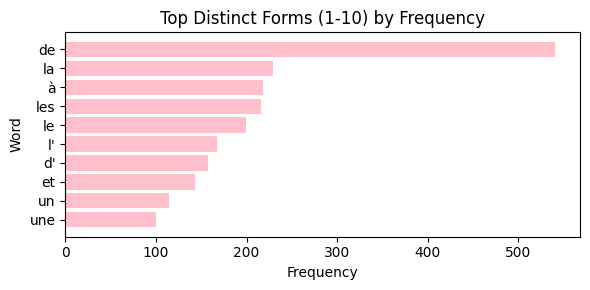

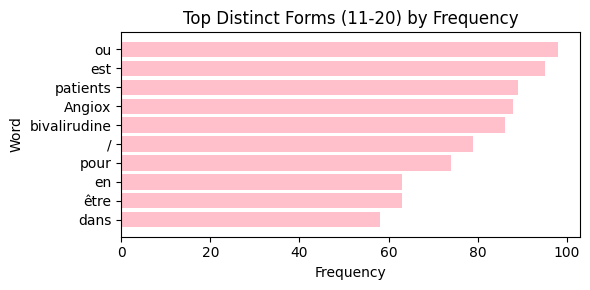

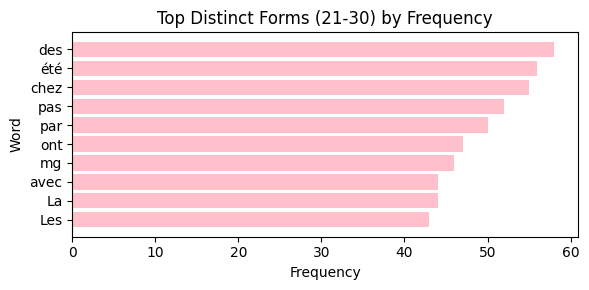

In [15]:
# Check if sorted_words exists and has enough data
if 'sorted_words' not in locals() or not sorted_words:
    print("Error: sorted_words is not defined or is empty. Please run the previous cells to populate it.")
else:
    # Limit to the top 30 words
    top_100_words = sorted_words[:30]

    # Define the number of words per chart
    words_per_chart = 10
    # Calculate the number of charts based on the top 100 words
    num_charts = len(top_100_words) // words_per_chart

    for i in range(num_charts):
        start_index = i * words_per_chart
        end_index = start_index + words_per_chart

        # Get the current chunk of words from the top_100_words list
        # These are already sorted from most frequent to least frequent
        current_words_chunk = top_100_words[start_index:end_index]

        # Separate words and counts for plotting
        # Horizontal bars, highest frequency at the top
        # -> reverse the order of words and counts within the chunk for plotting purposes
        words = [item[0] for item in current_words_chunk][::-1]
        counts = [item[1] for item in current_words_chunk][::-1]

        # Create a new figure and axes for each chart
        plt.figure(figsize=(6, 3))
        plt.barh(words, counts, color='pink') # Changed to barh for horizontal bars

        # Add labels and title (swapped for horizontal bars)
        plt.ylabel('Word')
        plt.xlabel('Frequency')
        plt.title(f'Top Distinct Forms ({start_index + 1}-{end_index}) by Frequency')

        # Adjust layout to prevent labels from overlapping
        plt.tight_layout()

        # Display the chart
        plt.show()

# 2.2. Computing category ambiguity rates

Compute, on the corpus, the following two measures and compare
them :
- POS-category ambiguity of distinct forms : the average number of possible
POS categories per inflected form (computed on the vocabulary of the corpus).
- POS-category ambiguity of tokens : the average number of possible POS
categories per token (computed on all token occurrences).

This corresponds to the typical distinction between types (distinct forms) and tokens
(form occurrences).

Example (French) :

> la/DET lutte/NC la/CL rebute/V mais/CC elle/CL lutte/V

- What is the POS-category ambiguity of the distinct forms?
- What is the POS-category ambiguity of the form occurrences?

Modify your programme so that it :
- computes both category ambiguity types defined above,
- prints each inflected form sorted by decreasing number of total occurrences,
- displays, for each form, the list of all POS categories it appears with at least once,
together with their respective occurrence counts, sorted by decreasing frequency.

You are allowed to use a dictionary of dictionaries :
- key = inflected form
- value = dictionary mapping POS tags to their counts.

## I. POS-category ambiguity of distinct forms

"inflected form" → count POS tags for separate surface form (parle, parles, parlons)

 "POS-category ambiguity of distinct forms" → how many different POS tags does it appear with?  → For each FORM (columns[1]), Collect all distinct UPOS (columns[3])

Added count POS tag per word into the loop

In [16]:
word_pos_counts["le"] # show tag

defaultdict(int, {'DET': 198, 'PRON': 1})

The type-level ambiguity is defined as:
$A_{\text{type}} = \frac{1}{|V|} \sum_{w \in V} \left| \mathrm{POS}(w) \right|$

- V = set of distinct surface forms

- ∣𝑉∣ = number of distinct forms (vocabulary size)

- POS(w) = set of POS categories observed for form
𝑤

- ∣POS(w)∣ = number of POS categories for that form


Print Sorted by Decreasing POS Frequency

In [17]:
# Compute total frequency per form
word_total_counts = {
    w: sum(pos_counts.values())
    for w, pos_counts in word_pos_counts.items()
}

# Keep only ambiguous forms
ambiguous_words = {
    w: pos_counts
    for w, pos_counts in word_pos_counts.items()
    if len(pos_counts) > 1
}

# Sort ambiguous forms by decreasing total frequency
sorted_ambiguous = sorted(
    ambiguous_words.keys(),
    key=lambda w: word_total_counts[w],
    reverse=True
)

# Print
for word in sorted_ambiguous:
    print(f"\n{word} (total: {word_total_counts[word]})")

    sorted_pos = sorted(
        word_pos_counts[word].items(),
        key=lambda x: x[1],
        reverse=True
    )

    for pos, count in sorted_pos:
        print(f"  {pos}: {count}")



de (total: 541)
  ADP: 531
  DET: 10

la (total: 229)
  DET: 226
  PRON: 3

les (total: 216)
  DET: 215
  PRON: 1

le (total: 199)
  DET: 198
  PRON: 1

l' (total: 167)
  DET: 164
  PRON: 3

d' (total: 158)
  ADP: 147
  DET: 11

un (total: 114)
  DET: 105
  PRON: 9

une (total: 100)
  DET: 99
  PRON: 1

est (total: 95)
  AUX: 91
  VERB: 4

/ (total: 79)
  SYM: 72
  CCONJ: 7

en (total: 63)
  ADP: 59
  PRON: 4

être (total: 63)
  AUX: 61
  NOUN: 2

ont (total: 47)
  AUX: 46
  VERB: 1

plus (total: 35)
  ADV: 30
  ADP: 5

que (total: 35)
  SCONJ: 34
  ADV: 1

a (total: 29)
  AUX: 28
  VERB: 1

ce (total: 16)
  PRON: 10
  DET: 6

comme (total: 13)
  ADP: 12
  SCONJ: 1

s' (total: 13)
  PRON: 11
  SCONJ: 2

qu' (total: 12)
  SCONJ: 10
  PRON: 1
  ADV: 1

avez (total: 12)
  VERB: 6
  AUX: 6

produit (total: 11)
  NOUN: 9
  VERB: 2

soit (total: 11)
  CCONJ: 6
  AUX: 5

ayant (total: 8)
  AUX: 6
  VERB: 2

même (total: 8)
  ADJ: 5
  ADV: 3

suivi (total: 7)
  VERB: 6
  NOUN: 1

A (total: 6)

In [18]:
print(len(ambiguous_words))

50


In [19]:
# Proportion of ambiguous word types
total_types = len(word_pos_counts)
ambiguous_types = len(ambiguous_words)

print(ambiguous_types / total_types)

0.026867275658248254


POS-category ambiguity of distinct forms:

In [20]:
#Average ambiguity per word type
avg_ambiguity = sum(len(pos_set) for pos_set in word_pos_counts.values()) / total_types
print(avg_ambiguity)

1.0279419666845782


## II. POS-category ambiguity of tokens

Tokens = form occurence = word frequency

The token-level ambiguity is defined as
$A_{\text{token}} = \frac{\sum_{w \in V} f(w)\, |\text{POS}(w)|}{\sum_{w \in V} f(w)}$.


Where
- 𝑉 = set of distinct surface forms (vocabulary)
- 𝑓(𝑤) = frequency of word form 𝑤
- POS(𝑤) = set of POS categories observed for
𝑤
- ∣POS(𝑤)∣ = number of POS categories for 𝑤

In [21]:
total_tokens = sum(word_counts.values())

weighted_sum = 0

for word in word_counts:
    ambiguity = len(word_pos_counts[word])
    freq = word_counts[word]
    weighted_sum += ambiguity * freq

token_ambiguity = weighted_sum / total_tokens

print(token_ambiguity)

1.2704618198445359


# 3.1 Reading a dependency tree

The file sequoia.conll contains 3,099
sentences from L’Est Républicain, EMEA, French Wikipedia, and Europarl, annotated
with morphological and syntactic information, more precisely dependency trees.

A dependency is represented as a triple (governor word, dependency label, dependent
word).

To familiarise yourself with this representation :
- draw the dependency tree for the second sentence in the file;
- identify the particularity of the root of this tree.

Write a programme that reads these dependency trees. Note that the CoNLL format
is not inherently suited to recursive reading. You may choose between :
- a non-recursive structure using a Node class and a Tree class that stores nodes,
governor and dependent relations;
- a recursive structure where each Tree instance contains node information and a
list of dependent subtrees.

In both cases, aim for a single pass over the sequence of words. Since one does not
know in advance where a sentence ends, you must handle a partially built tree structure.
Moreover, a governor may appear earlier than the line describing it, so you must manage
partially filled node instances and maintain a list of node instances for all positions in
the sentence, including in the recursive version.

what are:
 - dependent word: big
 - dependency label: adj
 - governor word (head)

possible solution:
- node (the word) and tree (its relations)
  - head, head-adj-Tom
- tree: node (the word) and dependent subtree (list of relation)
  - tree: head, toe-is-blue the-sucks

## I. Load and Overview

In [22]:
!wget --no-check-certificate https://www.linguist.univ-paris-diderot.fr/~mcandito/divers/sequoia.7.0.expanded.conll

--2026-02-21 09:11:57--  https://www.linguist.univ-paris-diderot.fr/~mcandito/divers/sequoia.7.0.expanded.conll
Resolving www.linguist.univ-paris-diderot.fr (www.linguist.univ-paris-diderot.fr)... 81.194.30.155
Connecting to www.linguist.univ-paris-diderot.fr (www.linguist.univ-paris-diderot.fr)|81.194.30.155|:443... connected.
  Unable to locally verify the issuer's authority.
HTTP request sent, awaiting response... 200 OK
Length: 2970942 (2.8M) [application/x-troff-man]
Saving to: ‘sequoia.7.0.expanded.conll’

sequoia.7.0.expande 100%[===================>]   2.83M  5.13MB/s    in 0.6s    

2026-02-21 09:11:58 (5.13 MB/s) - ‘sequoia.7.0.expanded.conll’ saved [2970942/2970942]



In [23]:
with open('/content/sequoia.7.0.expanded.conll', 'r', encoding='utf-8') as file2:
    for i, line in enumerate(file2):
        if i >= 50:
            break
        print(line.rstrip('\n'))

1	Gutenberg	Gutenberg	N	NPP	s=p|sentid=annodis.er_00001	0	root	_	_

1	Cette	ce	D	DET	g=f|n=s|s=dem|sentid=annodis.er_00002	2	det	_	_
2	exposition	exposition	N	NC	g=f|n=s|s=c	4	suj	_	_
3	nous	le/lui	CL	CLO	n=p|p=1|s=obj	4	a_obj	_	_
4	apprend	apprendre	V	V	m=ind|n=s|p=3|t=pst	0	root	_	_
5	que	que	C	CS	s=s	4	obj	_	_
6	dès	dès	P	P	_	21	mod	_	_
7	le	le	D	DET	g=m|n=s|s=def	9	det	_	_
8	XIIe	XIIe	A	ADJ	s=ord	9	mod	_	_
9	siècle	siècle	N	NC	g=m|n=s|s=c	6	obj.p	_	_
10	,	,	PONCT	PONCT	s=w	21	ponct	_	_
11	à	à	P	P	_	21	mod	_	_
12	Dammarie-sur-Saulx	Dammarie-sur-Saulx	N	NPP	g=m|n=s|s=p	11	obj.p	_	_
13	,	,	PONCT	PONCT	s=w	21	ponct	_	_
14	entre	entre	P	P	_	21	mod	_	_
15	autres	autre	A	ADJ	n=p|s=ind	16	mod	_	_
16	sites	site	N	NC	g=m|n=p|s=c	14	obj.p	_	_
17	,	,	PONCT	PONCT	s=w	21	ponct	_	_
18	une	un	D	DET	g=f|n=s|s=ind	19	det	_	_
19	industrie	industrie	N	NC	g=f|n=s|s=c	21	suj	_	_
20	métallurgique	métallurgique	A	ADJ	n=s|s=qual	19	mod	_	_
21	existait	exister	V	V	m=ind|n=s|p=3|t=impft	5	obj.cpl	_	_
22	.	.	

In [24]:
# Read file
with open("/content/sequoia.7.0.expanded.conll", "r", encoding="utf-8") as f:
    data = f.read()

sentences = parse(data) # Added this line to parse the data

num_sentences = len(sentences)

# Compute sentence lengths once
sentence_lengths = [
    len([tok for tok in s if isinstance(tok["id"], int)])
    for s in sentences
]

print("Sentences:", num_sentences)
print("Tokens:", sum(sentence_lengths))
print(f"Minimum sentence length:", min(sentence_lengths))
print(f"Maximum sentence length:", max(sentence_lengths))
print("Average sentence length:", sum(sentence_lengths) / num_sentences)


Sentences: 3099
Tokens: 68802
Minimum sentence length: 1
Maximum sentence length: 134
Average sentence length: 22.20135527589545


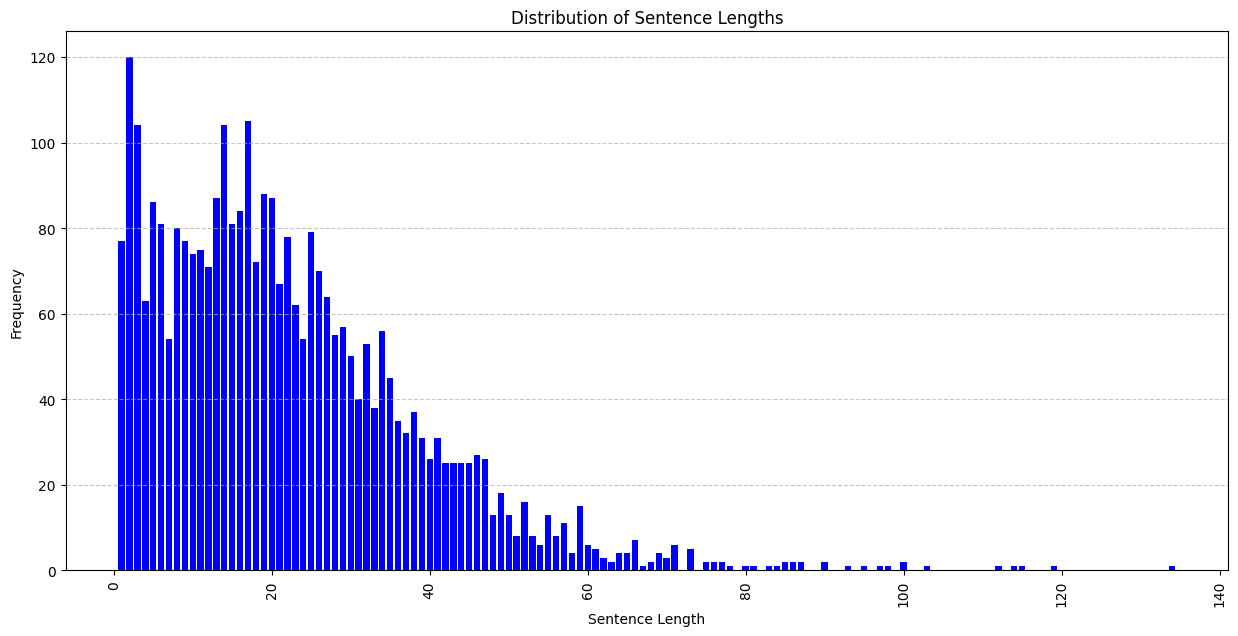

In [25]:
# Extract lengths and counts
length_counts = Counter(sentence_lengths)
sentence_length_distribution = sorted(length_counts.items())

lengths = [item[0] for item in sentence_length_distribution]
counts = [item[1] for item in sentence_length_distribution]

# Create the bar chart
plt.figure(figsize=(15, 7))
plt.bar(lengths, counts, color='blue')

# Add labels and title
plt.xlabel('Sentence Length')
plt.ylabel('Frequency')
plt.title('Distribution of Sentence Lengths')
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Display the plot
plt.show()

## II. Draw dependency tree for second sentence

In [26]:
sentences = parse(data)
sentence = sentences[1]  # second sentence

words = [token["form"] for token in sentence]
heads = [token["head"] - 1 for token in sentence]  # spaCy is 0-indexed
deps = [token["deprel"] for token in sentence]

vocab = Vocab()
doc = Doc(vocab, words=words)

for i, token in enumerate(doc):
    token.dep_ = deps[i]
    token.head = doc[heads[i]] if heads[i] >= 0 else token

displacy.render(doc, style="dep", jupyter=True)

The root word:
- One root per sentence
- It is the only node without a governor (head = 0)
- link to all other words (directly and indirectly)

## III. Read dependency tree
-> non-recursive structure using a Node class and a Tree class that stores node

- single pass
- maintain a list of node instances for all positions in the sentence

In [ ]:
# Node Class
class Node:
    def __init__(self, idx, form):
        self.id = idx
        self.form = form
        self.head = None      #govenor
        self.deprel = None    #dependency label
        self.children = []    #dependency word

# Tree Class
class Tree:
    def __init__(self):
        self.nodes = {}
        self.root = None

    def add_token(self, idx, form, head, deprel):
        # Create node if not exists
        if idx not in self.nodes:
            self.nodes[idx] = Node(idx, form)
        else:
            self.nodes[idx].form = form

        node = self.nodes[idx]
        node.deprel = deprel

        # Handle root
        if head == 0:
            self.root = node
        else:
            # Create placeholder head if needed
            if head not in self.nodes:
                self.nodes[head] = Node(head, None)

            node.head = self.nodes[head]
            self.nodes[head].children.append(node)

# Single pass reading
def read_conll(file_path):
    trees = []
    current_tree = Tree()

    with open(file_path, encoding="utf-8") as f:
        for line in f:
            line = line.strip()

            # Sentence boundary
            if not line:
                trees.append(current_tree)
                current_tree = Tree()
                continue

            if line.startswith("#"):
                continue

            parts = line.split("\t")
            idx = int(parts[0])
            form = parts[1]
            head = int(parts[6])
            deprel = parts[7]

            current_tree.add_token(idx, form, head, deprel)

    return trees

# 3.2 Estimation using relative frequency

**Probability estimation**

Consider verbs that have (at least one) nominal subject. Using the provided corpus, estimate by relative frequency :
- p=P(INV) : the probability that the subject is inverted (i.e. post-verbal),
- P(REL) : the probability that such a verb is the head of a relative clause,
- P(REL|INV) and P(INV | REL) : compute this in two ways — directly by restric
ting the fundamental set, and via Bayes’ theorem.

**Likelihood**

 Express the likelihood of the parameter p = P(INV), given the observations
(verb occurrences and the position of their subject). What property does the estimator
obtained in the previous section have? Provide a precise and developed explanation.